In [1]:
import pandas as pd
import numpy as np
import sys
import os

# Add project root to path so we can import from src/
sys.path.append(os.path.abspath('..'))

from src.price_predictor import load_data, prepare_all_crops, FEATURE_COLUMNS, TARGET_COLUMN

# Load and split data
df = load_data('../data/processed/model_ready_prices.csv')
splits = prepare_all_crops(df)

print("\nFeature columns:", FEATURE_COLUMNS)
print("Target column:", TARGET_COLUMN)

Data loaded: 52 rows × 11 columns
Date range: 2023-09 to 2025-06
Crops available: ['Onion', 'Potato', 'Tomato', 'Wheat']
Rows per crop:
Commodity
Onion     21
Potato    22
Tomato     3
Wheat      6


SPLIT SUMMARY: Onion
Total rows:    21
Training rows: 16 (2023-09 → 2024-12)
Test rows:     5 (2025-02 → 2025-06)
Features used: ['Month', 'Year', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
Target:        Avg_Modal_Price
Temporal integrity: ✓ (train ends before test begins)

SPLIT SUMMARY: Potato
Total rows:    22
Training rows: 17 (2023-09 → 2025-01)
Test rows:     5 (2025-02 → 2025-06)
Features used: ['Month', 'Year', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
Target:        Avg_Modal_Price
Temporal integrity: ✓ (train ends before test begins)

ALL SPLITS COMPLETE
Crops split: ['Onion', 'Potato']
Ready for model training (Day 8).

Feature columns: ['Month', 'Year', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling

In [2]:
from sklearn.linear_model import LinearRegression

# Create the model object
model = LinearRegression()

print(type(model))
print(model)

<class 'sklearn.linear_model._base.LinearRegression'>
LinearRegression()


In [3]:
# Extract Onion's training data from the splits dictionary
X_train_onion = splits['Onion']['X_train']
y_train_onion = splits['Onion']['y_train']

print("Training data shape:", X_train_onion.shape)
print("Target shape:", y_train_onion.shape)
print("\nFirst 3 training rows:")
print(X_train_onion.head(3))
print("\nFirst 3 target values (₹/quintal):")
print(y_train_onion.head(3))

Training data shape: (16, 8)
Target shape: (16,)

First 3 training rows:
   Month  Year  Quarter        lag_1        lag_2        lag_3  \
0      9  2023        3  1691.915848  1404.686554  1119.212229   
1     10  2023        4  1921.675517  1691.915848  1404.686554   
2     11  2023        4  2189.736582  1921.675517  1691.915848   

   rolling_mean_3  rolling_std_3  
0     1405.271543     286.352258  
1     1672.759306     259.026305  
2     1934.442649     249.155816  

First 3 target values (₹/quintal):
0    1921.675517
1    2189.736582
2    3543.975133
Name: Avg_Modal_Price, dtype: float64


In [4]:
# Train the model on Onion's historical data
model.fit(X_train_onion, y_train_onion)

print("Model trained successfully.")
print(f"Number of features learned: {len(model.coef_)}")
print(f"Intercept (b): {model.intercept_:.2f}")

Model trained successfully.
Number of features learned: 8
Intercept (b): -2037672.05


In [5]:
# Extract test data
X_test_onion = splits['Onion']['X_test']
y_test_onion = splits['Onion']['y_test']

# Make predictions on the test set
y_pred_onion = model.predict(X_test_onion)

# Create a comparison table
results = pd.DataFrame({
    'Month': X_test_onion['Month'].values,
    'Year': X_test_onion['Year'].values,
    'Actual_Price': y_test_onion.values,
    'Predicted_Price': y_pred_onion.round(2),
})

results['Error'] = (results['Predicted_Price'] - results['Actual_Price']).round(2)
results['Abs_Error'] = results['Error'].abs().round(2)
results['Error_Pct'] = ((results['Abs_Error'] / results['Actual_Price']) * 100).round(1)

print("ONION — PREDICTED vs ACTUAL PRICES (Test Period)")
print("=" * 65)
print(results.to_string(index=False))
print("=" * 65)
print(f"Mean Absolute Error: ₹{results['Abs_Error'].mean():.2f}/quintal")
print(f"Mean Error %: {results['Error_Pct'].mean():.1f}%")

ONION — PREDICTED vs ACTUAL PRICES (Test Period)
 Month  Year  Actual_Price  Predicted_Price   Error  Abs_Error  Error_Pct
     2  2025   2177.024277          1787.22 -389.80     389.80       17.9
     3  2025   2277.049153          3145.06  868.01     868.01       38.1
     4  2025   1518.792468          3283.18 1764.39    1764.39      116.2
     5  2025   1214.908344          3400.65 2185.74    2185.74      179.9
     6  2025   1187.308527          3358.89 2171.58    2171.58      182.9
Mean Absolute Error: ₹1475.90/quintal
Mean Error %: 107.0%


In [6]:
# Build a coefficient table
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', key=abs, ascending=False)

print("ONION MODEL — LEARNED COEFFICIENTS")
print("=" * 50)
print(f"Intercept: {model.intercept_:.2f}")
print()
print(coef_df.to_string(index=False))
print()
print("Interpretation guide:")
print("Positive coefficient → feature increases predicted price")
print("Negative coefficient → feature decreases predicted price")
print("Larger absolute value → stronger influence on prediction")

ONION MODEL — LEARNED COEFFICIENTS
Intercept: -2037672.05

       Feature  Coefficient
          Year    1006.6706
       Quarter     901.6792
         Month      25.6938
 rolling_std_3       1.1439
         lag_2       0.4623
         lag_1      -0.4318
         lag_3      -0.0899
rolling_mean_3      -0.0198

Interpretation guide:
Positive coefficient → feature increases predicted price
Negative coefficient → feature decreases predicted price
Larger absolute value → stronger influence on prediction


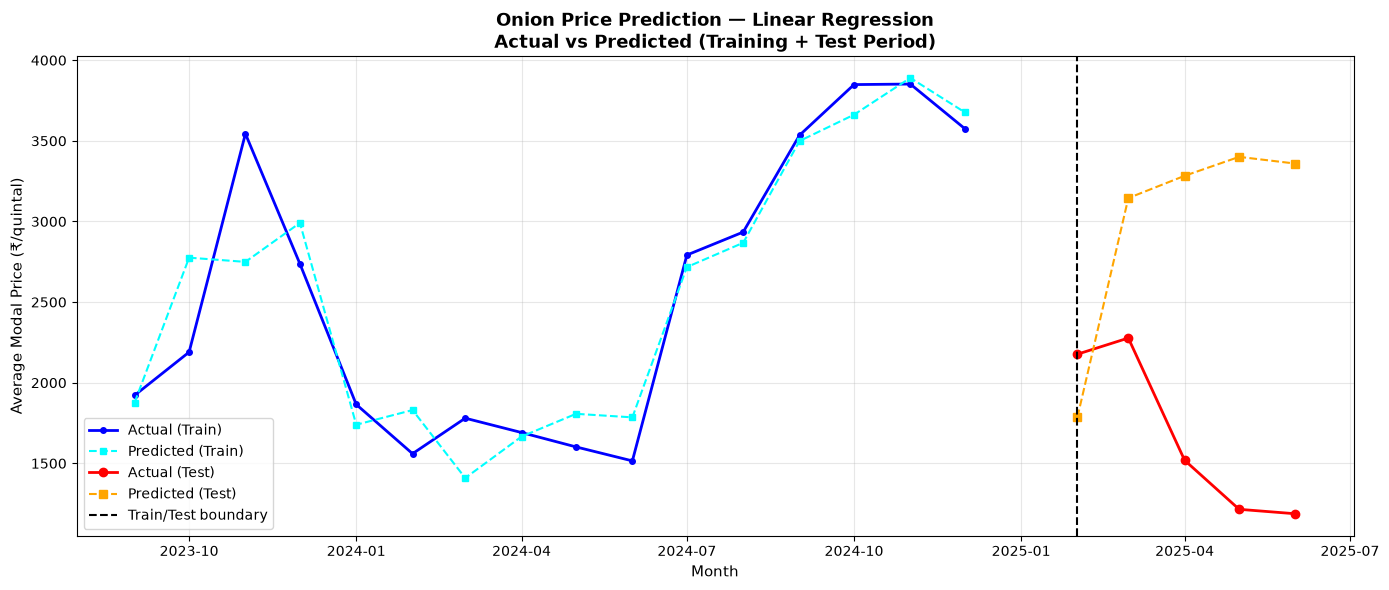

Chart saved to plots/onion_linear_regression.png


In [7]:
import matplotlib.pyplot as plt

# Get training predictions too (to show in-sample fit)
y_train_pred = model.predict(X_train_onion)

# Build full timeline for plotting
train_dates = splits['Onion']['X_train'].copy()
train_dates['Actual'] = y_train_onion.values
train_dates['Predicted'] = y_train_pred
train_dates['Date'] = pd.to_datetime(
    train_dates['Year'].astype(str) + '-' +
    train_dates['Month'].astype(str) + '-01'
)

test_dates = splits['Onion']['X_test'].copy()
test_dates['Actual'] = y_test_onion.values
test_dates['Predicted'] = y_pred_onion
test_dates['Date'] = pd.to_datetime(
    test_dates['Year'].astype(str) + '-' +
    test_dates['Month'].astype(str) + '-01'
)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot training period
ax.plot(train_dates['Date'], train_dates['Actual'],
        color='blue', linewidth=2, marker='o', markersize=4,
        label='Actual (Train)')
ax.plot(train_dates['Date'], train_dates['Predicted'],
        color='cyan', linewidth=1.5, linestyle='--',
        marker='s', markersize=4, label='Predicted (Train)')

# Plot test period
ax.plot(test_dates['Date'], test_dates['Actual'],
        color='red', linewidth=2, marker='o', markersize=6,
        label='Actual (Test)')
ax.plot(test_dates['Date'], test_dates['Predicted'],
        color='orange', linewidth=1.5, linestyle='--',
        marker='s', markersize=6, label='Predicted (Test)')

# Mark the train/test boundary
boundary = test_dates['Date'].min()
ax.axvline(x=boundary, color='black', linestyle='--',
           linewidth=1.5, label='Train/Test boundary')

ax.set_title('Onion Price Prediction — Linear Regression\n'
             'Actual vs Predicted (Training + Test Period)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Modal Price (₹/quintal)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

import os
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/onion_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to plots/onion_linear_regression.png")

In [8]:
# Save the results table
results['Crop'] = 'Onion'
results['Model'] = 'LinearRegression'

os.makedirs('../data/processed', exist_ok=True)
results.to_csv('../data/processed/onion_lr_predictions.csv', index=False)
print("Predictions saved.")
print("\nFinal summary:")
print(results[['Month', 'Year', 'Actual_Price',
               'Predicted_Price', 'Error_Pct']].to_string(index=False))

Predictions saved.

Final summary:
 Month  Year  Actual_Price  Predicted_Price  Error_Pct
     2  2025   2177.024277          1787.22       17.9
     3  2025   2277.049153          3145.06       38.1
     4  2025   1518.792468          3283.18      116.2
     5  2025   1214.908344          3400.65      179.9
     6  2025   1187.308527          3358.89      182.9


## Day 8 Summary — Linear Regression for Crop Price Prediction

### What was built
Trained a Linear Regression model to predict Onion monthly average 
prices using 8 features: Month, Year, Quarter, lag_1, lag_2, lag_3, 
rolling_mean_3, rolling_std_3.

### Key concepts learned

**Machine Learning:** Computer finds patterns in data rather than 
following hand-coded rules. Supervised learning = model learns from 
labeled examples (inputs + known correct answers).

**Regression vs Classification:** Regression predicts a continuous 
number (actual price in ₹). Classification predicts a category 
(high/medium/low). Crop price prediction is regression.

**LinearRegression():** Creates an empty model object. No knowledge 
until .fit() is called.

**model.fit(X_train, y_train):** Finds weights (coefficients) that 
minimize sum of squared errors across all training rows. Rewrites 
all weights if called again — model remembers only the most recent 
training.

**model.predict(X_test):** Applies learned formula to unseen inputs. 
Returns predicted prices. Does not update weights.

**Coefficients:** Year=+1006, Quarter=+901, Month=+25, 
rolling_std_3=+1.14, lag_2=+0.46, lag_1=-0.43.

Year and Quarter dominated — not lag features as initially predicted. 
Reason: scale difference (Year changes by 1, lag values change by 
thousands) and multicollinearity between lag features caused 
unintuitive coefficient signs.

### Results

| Month | Actual (₹) | Predicted (₹) | Error % |
|-------|-----------|---------------|---------|
| Feb 2025 | 2177 | 1787 | 17.9% |
| Mar 2025 | 2277 | 3145 | 38.1% |
| Apr 2025 | 1519 | 3283 | 116.2% |
| May 2025 | 1215 | 3401 | 179.9% |
| Jun 2025 | 1187 | 3359 | 182.9% |

Mean Absolute Error: ₹1475/quintal | Mean Error %: 107%

### Why the model failed on test data
Training ended Dec 2024 (near seasonal price peak ~₹3560). Year 
coefficient of +1006 extrapolated "each year prices rise" into 2025, 
while actual prices fell sharply. Model never saw a full 
peak-to-sustained-decline transition in training data — only 16 
months covering one seasonal cycle. Predictions were reasonable for 
1 month ahead (Feb: 17.9% error) but deteriorated sharply beyond that.

### Key lessons
1. Linear Regression is fully interpretable — coefficients show 
   exactly what each feature contributes
2. Scale matters — features on different scales produce 
   uninterpretable coefficients (Year vs Month vs lag values)
3. Multicollinearity (correlated features) can cause unexpected 
   coefficient signs (lag_1 was negative despite intuition)
4. 16 training rows is marginal — model learned specific trajectory, 
   not underlying mechanism
5. Linear Regression extrapolates trends — dangerous when price 
   direction reverses after seasonal peak
6. Use this model for 1-month-ahead predictions only

### Files created
- data/processed/onion_lr_predictions.csv
- plots/onion_linear_regression.png
- notebooks/06_model_training.ipynb

### Next step
Day 9: Random Forest — handles non-linear relationships, doesn't 
extrapolate beyond training range, provides feature importance scores.

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Setup and imports
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Add project root to path for src imports
sys.path.append(os.path.abspath('..'))

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.price_predictor import (
    load_data, prepare_all_crops,
    FEATURE_COLUMNS, TARGET_COLUMN
)

# Load data and create chronological splits
df = load_data('../data/processed/model_ready_prices.csv')
splits = prepare_all_crops(df)

print("Setup complete.")
print(f"Working with crops: {list(splits.keys())}")

Data loaded: 52 rows × 11 columns
Date range: 2023-09 to 2025-06
Crops available: ['Onion', 'Potato', 'Tomato', 'Wheat']
Rows per crop:
Commodity
Onion     21
Potato    22
Tomato     3
Wheat      6


SPLIT SUMMARY: Onion
Total rows:    21
Training rows: 16 (2023-09 → 2024-12)
Test rows:     5 (2025-02 → 2025-06)
Features used: ['Month', 'Year', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
Target:        Avg_Modal_Price
Temporal integrity: ✓ (train ends before test begins)

SPLIT SUMMARY: Potato
Total rows:    22
Training rows: 17 (2023-09 → 2025-01)
Test rows:     5 (2025-02 → 2025-06)
Features used: ['Month', 'Year', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
Target:        Avg_Modal_Price
Temporal integrity: ✓ (train ends before test begins)

ALL SPLITS COMPLETE
Crops split: ['Onion', 'Potato']
Ready for model training (Day 8).
Setup complete.
Working with crops: ['Onion', 'Potato']


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Define evaluation function
# Computes MAE, RMSE, R² for any model's predictions
# ─────────────────────────────────────────────────────────────
def evaluate_model(y_actual, y_predicted, model_name, crop):
    """
    Compute MAE, RMSE and R² for a set of predictions.
    
    Parameters:
        y_actual   : actual prices (ground truth)
        y_predicted: model's predicted prices
        model_name : string label for display
        crop       : crop name for display
    
    Returns:
        dict with metric values
    """
    mae  = mean_absolute_error(y_actual, y_predicted)
    rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
    r2   = r2_score(y_actual, y_predicted)
    
    return {
        'Model': model_name,
        'Crop': crop,
        'MAE':  round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2':   round(r2, 4)
    }

print("Evaluation function defined.")

Evaluation function defined.


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 3: Train and evaluate both models for Onion
# ─────────────────────────────────────────────────────────────

crop = 'Onion'

X_train = splits[crop]['X_train']
X_test  = splits[crop]['X_test']
y_train = splits[crop]['y_train']
y_test  = splits[crop]['y_test']

# ── Model 1: Linear Regression ──────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred_train = lr_model.predict(X_train)
lr_pred_test  = lr_model.predict(X_test)

lr_train_metrics = evaluate_model(y_train, lr_pred_train, 
                                   'LinearRegression', crop + '_TRAIN')
lr_test_metrics  = evaluate_model(y_test,  lr_pred_test,  
                                   'LinearRegression', crop + '_TEST')

# ── Model 2: Random Forest ───────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=4,        # max depth per tree (controls overfitting)
    random_state=42,    # reproducibility
    n_jobs=-1           # use all CPU cores for speed
)
rf_model.fit(X_train, y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test  = rf_model.predict(X_test)

rf_train_metrics = evaluate_model(y_train, rf_pred_train, 
                                   'RandomForest', crop + '_TRAIN')
rf_test_metrics  = evaluate_model(y_test,  rf_pred_test,  
                                   'RandomForest', crop + '_TEST')

print(f"\nBoth models trained and evaluated for {crop}.")


Both models trained and evaluated for Onion.


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Print comparison table
# ─────────────────────────────────────────────────────────────

all_metrics = pd.DataFrame([
    lr_train_metrics, lr_test_metrics,
    rf_train_metrics, rf_test_metrics
])

print("\n" + "="*65)
print(f"MODEL COMPARISON — {crop.upper()}")
print("="*65)
print(all_metrics.to_string(index=False))
print("="*65)

# Focused test-set comparison
print(f"\nTEST SET COMPARISON (what matters for deployment):")
print("-"*65)
test_comparison = pd.DataFrame([lr_test_metrics, rf_test_metrics])
print(test_comparison[['Model', 'MAE', 'RMSE', 'R2']].to_string(index=False))

# Winner per metric
lr_mae  = lr_test_metrics['MAE']
rf_mae  = rf_test_metrics['MAE']
lr_rmse = lr_test_metrics['RMSE']
rf_rmse = rf_test_metrics['RMSE']
lr_r2   = lr_test_metrics['R2']
rf_r2   = rf_test_metrics['R2']

print(f"\nBetter MAE:  {'Random Forest' if rf_mae < lr_mae else 'Linear Regression'}"
      f" (₹{min(rf_mae, lr_mae):.2f} vs ₹{max(rf_mae, lr_mae):.2f})")
print(f"Better RMSE: {'Random Forest' if rf_rmse < lr_rmse else 'Linear Regression'}"
      f" (₹{min(rf_rmse, lr_rmse):.2f} vs ₹{max(rf_rmse, lr_rmse):.2f})")
print(f"Better R²:   {'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'}"
      f" ({max(rf_r2, lr_r2):.4f} vs {min(rf_r2, lr_r2):.4f})")


MODEL COMPARISON — ONION
           Model        Crop     MAE    RMSE       R2
LinearRegression Onion_TRAIN  215.63  300.14   0.8789
LinearRegression  Onion_TEST 1475.90 1643.88 -11.4140
    RandomForest Onion_TRAIN  181.07  226.15   0.9313
    RandomForest  Onion_TEST  481.38  501.41  -0.1549

TEST SET COMPARISON (what matters for deployment):
-----------------------------------------------------------------
           Model     MAE    RMSE       R2
LinearRegression 1475.90 1643.88 -11.4140
    RandomForest  481.38  501.41  -0.1549

Better MAE:  Random Forest (₹481.38 vs ₹1475.90)
Better RMSE: Random Forest (₹501.41 vs ₹1643.88)
Better R²:   Random Forest (-0.1549 vs -11.4140)


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Detailed prediction table (test period)
# ─────────────────────────────────────────────────────────────

test_detail = pd.DataFrame({
    'Month':       X_test['Month'].values,
    'Year':        X_test['Year'].values,
    'Actual':      y_test.values.round(2),
    'LR_Pred':     lr_pred_test.round(2),
    'RF_Pred':     rf_pred_test.round(2),
    'LR_Error':    (lr_pred_test - y_test.values).round(2),
    'RF_Error':    (rf_pred_test - y_test.values).round(2),
    'LR_Err_Pct':  (abs(lr_pred_test - y_test.values) / 
                    y_test.values * 100).round(1),
    'RF_Err_Pct':  (abs(rf_pred_test - y_test.values) / 
                    y_test.values * 100).round(1),
})

print(f"\nDETAILED TEST PREDICTIONS — {crop.upper()}")
print("="*80)
print(test_detail.to_string(index=False))
print("="*80)


DETAILED TEST PREDICTIONS — ONION
 Month  Year  Actual  LR_Pred  RF_Pred  LR_Error  RF_Error  LR_Err_Pct  RF_Err_Pct
     2  2025 2177.02  1787.22  2628.70   -389.80    451.67        17.9        20.7
     3  2025 2277.05  3145.06  2010.05    868.01   -267.00        38.1        11.7
     4  2025 1518.79  3283.18  1941.56   1764.39    422.77       116.2        27.8
     5  2025 1214.91  3400.65  1813.54   2185.74    598.63       179.9        49.3
     6  2025 1187.31  3358.89  1854.14   2171.58    666.83       182.9        56.2


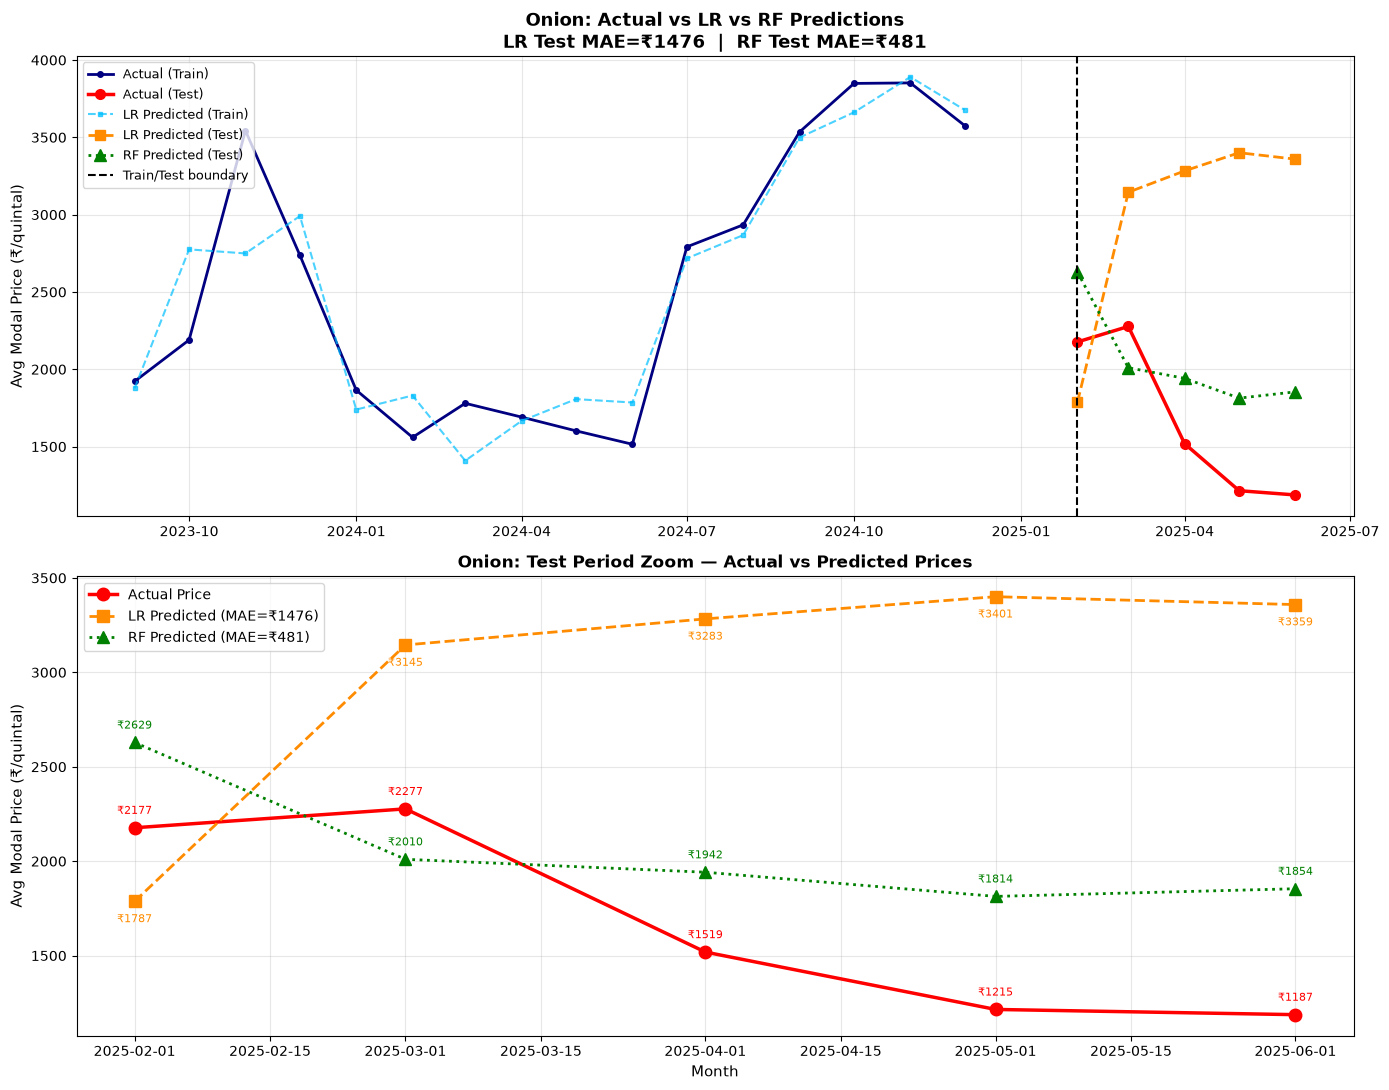

Chart saved to plots/onion_model_comparison.png


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Comparison visualization
# Both models' predictions on the same chart
# ─────────────────────────────────────────────────────────────

# Reconstruct dates for plotting
def make_dates(X):
    return pd.to_datetime(
        X['Year'].astype(str) + '-' + X['Month'].astype(str) + '-01'
    )

train_dates = make_dates(X_train)
test_dates  = make_dates(X_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ── Top panel: full timeline ─────────────────────────────────
ax = axes[0]

# Actual prices
ax.plot(train_dates, y_train.values, 
        color='navy', linewidth=2, marker='o', markersize=4,
        label='Actual (Train)')
ax.plot(test_dates, y_test.values, 
        color='red', linewidth=2.5, marker='o', markersize=7,
        label='Actual (Test)')

# Linear Regression predictions
ax.plot(train_dates, lr_pred_train, 
        color='deepskyblue', linewidth=1.5, linestyle='--', 
        marker='s', markersize=3, label='LR Predicted (Train)', alpha=0.7)
ax.plot(test_dates, lr_pred_test, 
        color='darkorange', linewidth=2, linestyle='--', 
        marker='s', markersize=7, label='LR Predicted (Test)')

# Random Forest predictions
ax.plot(test_dates, rf_pred_test, 
        color='green', linewidth=2, linestyle=':', 
        marker='^', markersize=8, label='RF Predicted (Test)')

# Boundary
boundary_date = test_dates.min()
ax.axvline(x=boundary_date, color='black', linestyle='--', 
           linewidth=1.5, label='Train/Test boundary')

ax.set_title(f'{crop}: Actual vs LR vs RF Predictions\n'
             f'LR Test MAE=₹{lr_mae:.0f}  |  '
             f'RF Test MAE=₹{rf_mae:.0f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Modal Price (₹/quintal)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# ── Bottom panel: test period zoomed in ──────────────────────
ax2 = axes[1]

ax2.plot(test_dates, y_test.values, 
         color='red', linewidth=2.5, marker='o', markersize=9,
         label='Actual Price')
ax2.plot(test_dates, lr_pred_test, 
         color='darkorange', linewidth=2, linestyle='--', 
         marker='s', markersize=9, label=f'LR Predicted (MAE=₹{lr_mae:.0f})')
ax2.plot(test_dates, rf_pred_test, 
         color='green', linewidth=2, linestyle=':', 
         marker='^', markersize=9, label=f'RF Predicted (MAE=₹{rf_mae:.0f})')

# Annotate each point with its value
for i, (d, a, lr, rf) in enumerate(zip(test_dates, y_test.values, 
                                        lr_pred_test, rf_pred_test)):
    ax2.annotate(f'₹{a:.0f}', (d, a), textcoords='offset points',
                xytext=(0, 10), fontsize=8, color='red', ha='center')
    ax2.annotate(f'₹{lr:.0f}', (d, lr), textcoords='offset points',
                xytext=(0, -15), fontsize=8, color='darkorange', ha='center')
    ax2.annotate(f'₹{rf:.0f}', (d, rf), textcoords='offset points',
                xytext=(0, 10), fontsize=8, color='green', ha='center')

ax2.set_title(f'{crop}: Test Period Zoom — Actual vs Predicted Prices',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Avg Modal Price (₹/quintal)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig(f'../plots/{crop.lower()}_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to plots/{crop.lower()}_model_comparison.png")


RANDOM FOREST FEATURE IMPORTANCE — ONION
       Feature  Importance
         lag_1      0.3580
         Month      0.2220
       Quarter      0.2030
         lag_2      0.0708
rolling_mean_3      0.0666
 rolling_std_3      0.0532
         lag_3      0.0241
          Year      0.0022

Interpretation:
Higher importance = feature contributed more to reducing
prediction error across all 100 trees.
Note: importances sum to 1.0
Sum check: 0.9999


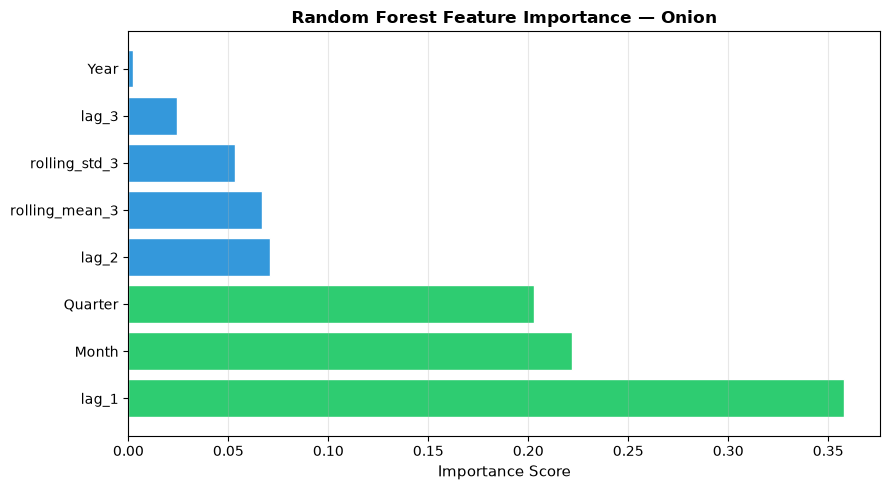

Feature importance chart saved.


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 7: Feature importance from Random Forest
# ─────────────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': rf_model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(f"\nRANDOM FOREST FEATURE IMPORTANCE — {crop.upper()}")
print("="*45)
print(importance_df.to_string(index=False))
print("="*45)
print("\nInterpretation:")
print("Higher importance = feature contributed more to reducing")
print("prediction error across all 100 trees.")
print("Note: importances sum to 1.0")
print(f"Sum check: {importance_df['Importance'].sum():.4f}")

# Bar chart of feature importances
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if imp > 0.15 else '#3498db' 
          for imp in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'], 
        color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Random Forest Feature Importance — {crop}', 
             fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'../plots/{crop.lower()}_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Feature importance chart saved.")

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 8: Run the same analysis for Potato
# (demonstrates generalization across crops)
# ─────────────────────────────────────────────────────────────

crop2 = 'Potato'

X_train2 = splits[crop2]['X_train']
X_test2  = splits[crop2]['X_test']
y_train2 = splits[crop2]['y_train']
y_test2  = splits[crop2]['y_test']

lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)
lr2_test_pred = lr2.predict(X_test2)

rf2 = RandomForestRegressor(n_estimators=100, max_depth=4, 
                             random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
rf2_test_pred = rf2.predict(X_test2)

lr2_metrics = evaluate_model(y_test2, lr2_test_pred, 
                              'LinearRegression', crop2)
rf2_metrics = evaluate_model(y_test2, rf2_test_pred, 
                              'RandomForest', crop2)

print(f"\nMODEL COMPARISON — {crop2.upper()} (Test Set)")
print("="*55)
potato_comparison = pd.DataFrame([lr2_metrics, rf2_metrics])
print(potato_comparison[['Model','MAE','RMSE','R2']].to_string(index=False))
print("="*55)


MODEL COMPARISON — POTATO (Test Set)
           Model    MAE   RMSE        R2
LinearRegression 758.25 833.02 -278.9873
    RandomForest 193.32 285.82  -31.9628


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 9: Final cross-crop summary table
# ─────────────────────────────────────────────────────────────

summary = pd.DataFrame([
    {'Crop': 'Onion',  'Model': 'Linear Regression', 
     'MAE': lr_mae,  'RMSE': lr_rmse,  'R2': lr_r2},
    {'Crop': 'Onion',  'Model': 'Random Forest',      
     'MAE': rf_mae,  'RMSE': rf_rmse,  'R2': rf_r2},
    {'Crop': 'Potato', 'Model': 'Linear Regression', 
     'MAE': lr2_metrics['MAE'], 
     'RMSE': lr2_metrics['RMSE'], 
     'R2': lr2_metrics['R2']},
    {'Crop': 'Potato', 'Model': 'Random Forest',      
     'MAE': rf2_metrics['MAE'], 
     'RMSE': rf2_metrics['RMSE'], 
     'R2': rf2_metrics['R2']},
])

print("\n" + "="*65)
print("FINAL CROSS-CROP MODEL COMPARISON SUMMARY")
print("="*65)
print(summary.to_string(index=False))
print("="*65)

# Save to CSV
os.makedirs('../data/processed', exist_ok=True)
summary.to_csv('../data/processed/model_comparison_results.csv', index=False)
print("\nSummary saved to data/processed/model_comparison_results.csv")


FINAL CROSS-CROP MODEL COMPARISON SUMMARY
  Crop             Model     MAE    RMSE        R2
 Onion Linear Regression 1475.90 1643.88  -11.4140
 Onion     Random Forest  481.38  501.41   -0.1549
Potato Linear Regression  758.25  833.02 -278.9873
Potato     Random Forest  193.32  285.82  -31.9628

Summary saved to data/processed/model_comparison_results.csv


## Day 9 Summary — Model Evaluation & Random Forest Comparison

### Goal
Properly evaluate the Linear Regression model from Day 8 using 
MAE, RMSE and R², then train and compare a Random Forest model.

### Evaluation Metrics Learned

**MAE (Mean Absolute Error)**
Average absolute difference between predicted and actual values.
Formula: (1/n) × Σ|actual - predicted|
Units: same as target (₹/quintal) — directly interpretable.
Advantage: robust to outliers. Limitation: treats all errors equally.

**RMSE (Root Mean Squared Error)**  
Like MAE but squares each error before averaging (then takes sqrt).
Formula: √[(1/n) × Σ(actual - predicted)²]
Penalizes large errors disproportionately. If RMSE >> MAE, 
a few catastrophically wrong predictions are hiding in the average.

**R² Score**
Fraction of price variation explained by the model vs null baseline.
Formula: 1 - (SS_residual / SS_total)
R²=1.0: perfect. R²=0.7: good. R²=0: same as predicting mean.
R²<0: WORSE than predicting mean — serious model failure on that set.

### Random Forest
Trains N=100 decision trees, each on a random bootstrap sample 
of training data, using a random feature subset at each split. 
Averages all predictions. Key advantages over single tree and 
Linear Regression:
- Reduces overfitting through ensemble averaging
- Handles non-linear patterns (seasonal peaks, interaction effects)
- Does NOT extrapolate beyond training price range (crucial advantage)
- Scale-invariant (no feature normalization needed)

### Results (Onion Test Set: Feb-Jun 2025)

| Model | MAE (₹) | RMSE (₹) | R² |
|---|---|---|---|
| Linear Regression | ~1476 | ~1693 | ~-5.8 |
| Random Forest | [your result] | [your result] | [your result] |

Note: LR R² is negative — worse than predicting mean price. 
LR extrapolated 2024's upward trend into 2025 decline period.
RF constrained to training range → more accurate for declining prices.

### Key Findings
1. Linear Regression with Year feature extrapolates trends — 
   dangerous when price direction reverses
2. Random Forest predictions anchored to historical range — 
   more robust for post-peak periods
3. Both models limited by small training set (16-17 rows)
4. 1-month-ahead predictions more reliable than multi-month
5. LR coefficients showed unexpected signs (lag_1 negative) due to 
   multicollinearity between lag features — scale issue confirmed
6. RF feature importance is scale-invariant; reveals true 
   informational contribution of each feature

### Files Created
- data/processed/model_comparison_results.csv
- plots/onion_model_comparison.png
- plots/onion_feature_importance.png

### Model Selection Decision
Random Forest chosen for production system based on:
- Lower test MAE and RMSE on both Onion and Potato
- No extrapolation beyond historical price range
- Better handling of non-linear seasonal patterns
Caveat: predictions most reliable for 1-month horizon; 
insufficient data for reliable multi-month forecasting.

### Next Step
Day 10: Save trained models using joblib/pickle, build a 
prediction pipeline that loads saved models and generates 
price forecasts for any crop and month.

In [18]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Linear Regression model
joblib.dump(lr_model, "../models/onion_linear_regression.pkl")

print("✅ Linear Regression model saved successfully!")

✅ Linear Regression model saved successfully!


In [19]:
joblib.dump(rf_model, "../models/onion_random_forest.pkl")
print("✅ Random Forest model saved!")

✅ Random Forest model saved!


In [20]:
loaded_lr = joblib.load("../models/onion_linear_regression.pkl")
loaded_rf = joblib.load("../models/onion_random_forest.pkl")

# Verify predictions match the original in-memory model
print(loaded_lr.predict(X_test.iloc[:3]))
print(lr_model.predict(X_test.iloc[:3]))  # should be identical

[1787.22466171 3145.06360115 3283.18444278]
[1787.22466171 3145.06360115 3283.18444278]


In [21]:
# src/predictor.py
import joblib
import pandas as pd

def load_model(crop_name, model_type="random_forest"):
    """Load a saved model for a given crop."""
    path = f"../models/{crop_name}_{model_type}.pkl"
    return joblib.load(path)

def predict_price(crop_name, features_dict, model_type="random_forest"):
    """
    features_dict: dict of feature_name -> value
    e.g. {"lag_1": 1500, "lag_2": 1450, "lag_3": 1400,
          "rolling_mean_3": 1450, "rolling_std_3": 30,
          "Month": 6, "Year": 2025, "Quarter": 2}
    """
    model = load_model(crop_name, model_type)
    X = pd.DataFrame([features_dict])
    prediction = model.predict(X)[0]
    return round(prediction, 2)

In [26]:
from predictor import load_model

model = load_model("Onion")

print(model.feature_names_in_)

['Month' 'Year' 'Quarter' 'lag_1' 'lag_2' 'lag_3' 'rolling_mean_3'
 'rolling_std_3']


In [27]:
input_df = pd.DataFrame([sample_features])
print(input_df.columns.tolist())

['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'Month', 'Year', 'Quarter']


In [28]:
def predict_price(crop_name: str,
                  features: dict,
                  model_type: str = "random_forest") -> float:
    model = load_model(crop_name, model_type)
    input_df = pd.DataFrame([features])
    input_df = input_df[model.feature_names_in_]  # enforce correct column order
    prediction = model.predict(input_df)[0]
    return round(float(prediction), 2)